In [235]:
%load_ext autoreload
%autoreload 2

import sys
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [236]:
sys.path.append(os.path.abspath('../..')) 
from src.xai.xai_baseExplainer import BaseExplainer

model_path = "../../models/best_models_cnn_lstm/best_cnn_lstm_FD001.keras"
x_path = "../../data/processed_data/X_test_FD001.npz"
y_path = "../../data/processed_data/y_test_FD001.npz"

#Inicia a classe Base
base = BaseExplainer(model_path, x_path, y_path)

## Testando se as funções estão funcionando.

In [237]:
indice = 0

print(f"--- TESTE: AMOSTRA {indice} ---")
print(f"Shape retornado: {base.get_instance(indice).shape}")
print(f"RUL Real: {base.get_true_rul(indice)}")
print(f"RUL Predito: {base.get_prediction(indice):.2f}")

--- TESTE: AMOSTRA 0 ---
Shape retornado: (1, 30, 19)
RUL Real: 113
RUL Predito: 120.95


## ShapExplainer

In [238]:
from src.xai.xai_shapExplainer import ShapExplainer

model_path = "../../models/best_models_cnn_lstm/best_cnn_lstm_FD001.keras"
x_path = "../../data/processed_data/X_test_FD001.npz"
y_path = "../../data/processed_data/y_test_FD001.npz"

explainer_shap = ShapExplainer(model_path, x_path, y_path)

In [239]:
idx_amostra = 0
print(f"Calculando SHAP para a amostra {idx_amostra}...")
shap_values = explainer_shap.explain_instance(idx_amostra)

print(f"RUL Real: {explainer_shap.get_true_rul(idx_amostra)}")
print(f"RUL Previsto: {explainer_shap.get_prediction(idx_amostra):.2f}")
print(f"Shape original dos SHAP values: {shap_values.shape}")

Calculando SHAP para a amostra 0...


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(1, 30, 19))']
  warnings.warn(msg)
C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(50, 30, 19))']
  warnings.warn(msg)


RUL Real: 113
RUL Previsto: 120.95
Shape original dos SHAP values: (1, 30, 19, 1)


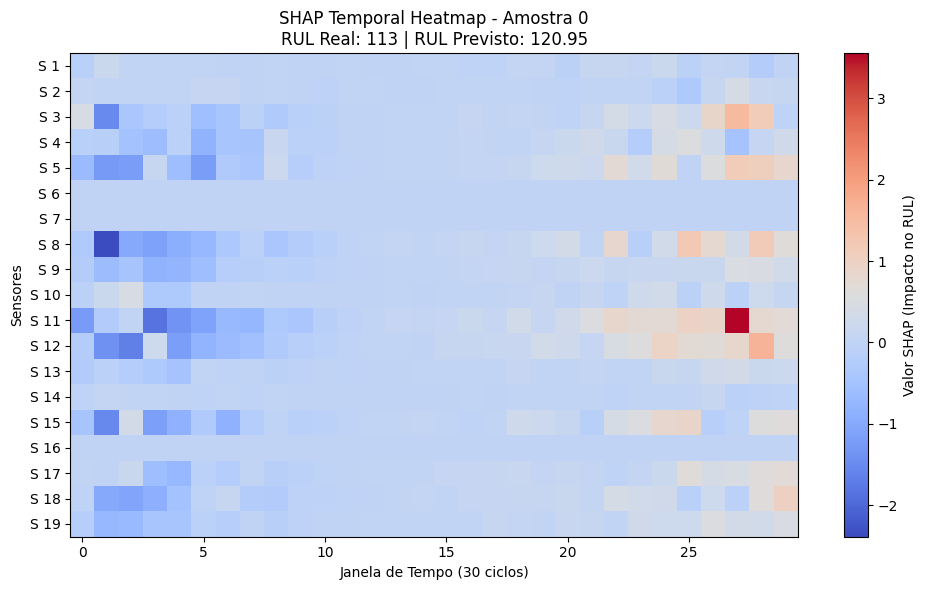

In [240]:
explainer_shap.plot_temporal_heatmap(idx_amostra)

C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(1, 30, 19))']
  warnings.warn(msg)


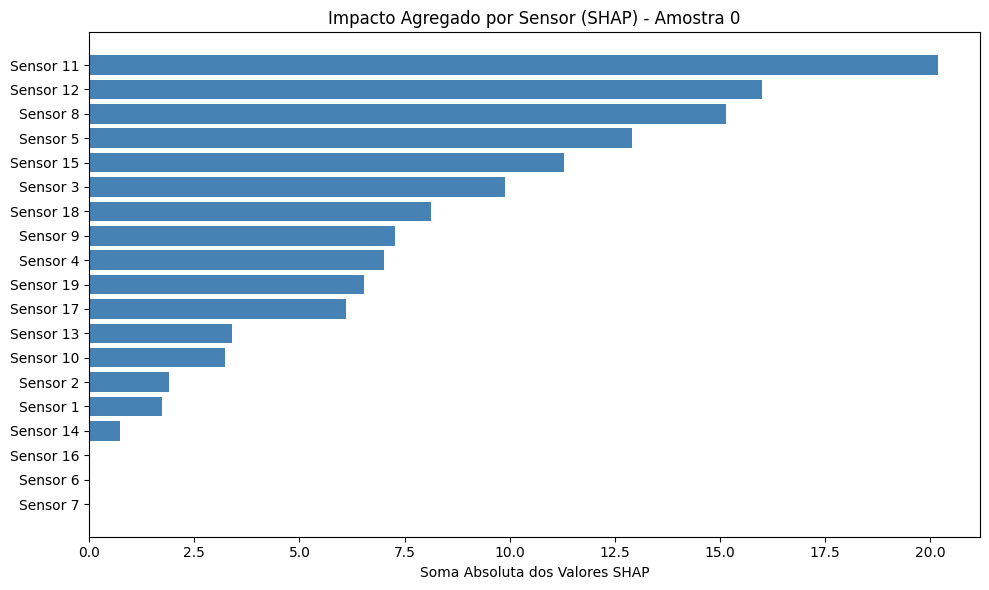

In [241]:
explainer_shap.plot_sensor_importance_bar(idx_amostra)

Calculando SHAP para 100 amostras (isso pode levar alguns segundos)...


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(100, 30, 19))']
  warnings.warn(msg)
c:\Users\davis\Documents\vscode\Turbofan-Engine-Degradation-Mestrado\src\xai\xai_shapExplainer.py:82: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_2d, instances_2d, feature_names=sensores_labels, show=False)


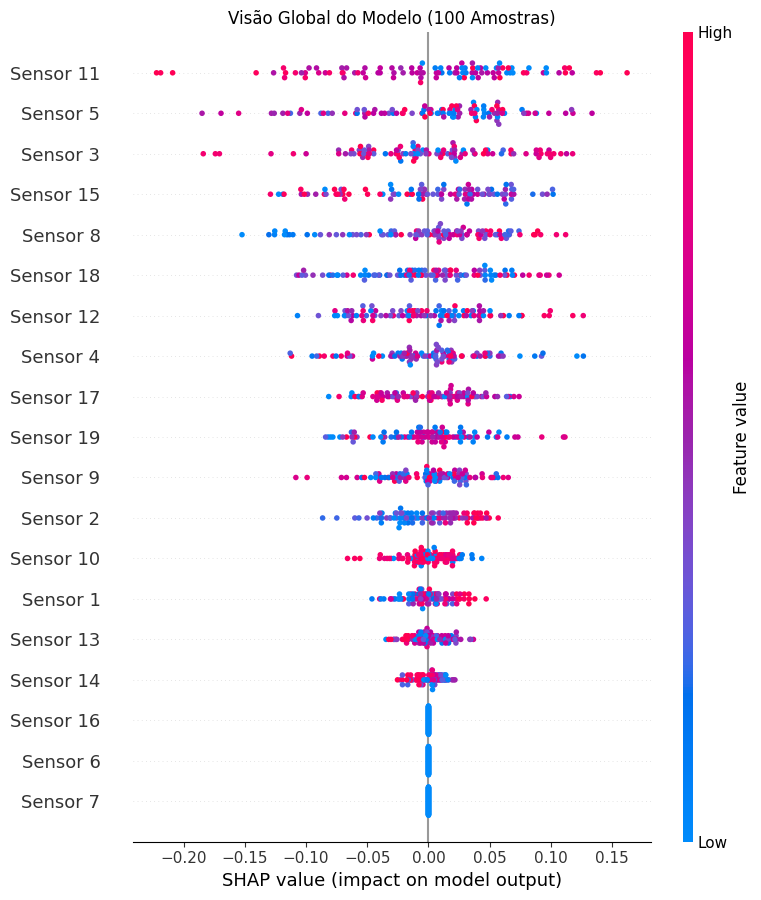

In [242]:
# Testa a visão global com as primeiras 50 máquinas
explainer_shap.plot_global_summary()

## LimeExplainer

In [243]:
from src.xai.xai_limeExplainer import LimeExplainer

model_path = "../../models/best_models_cnn_lstm/best_cnn_lstm_FD001.keras"
x_path = "../../data/processed_data/X_test_FD001.npz"
y_path = "../../data/processed_data/y_test_FD001.npz"

lime_explainer = LimeExplainer(model_path, x_path, y_path)

RUL Real: 113 | RUL Previsto: 120.95


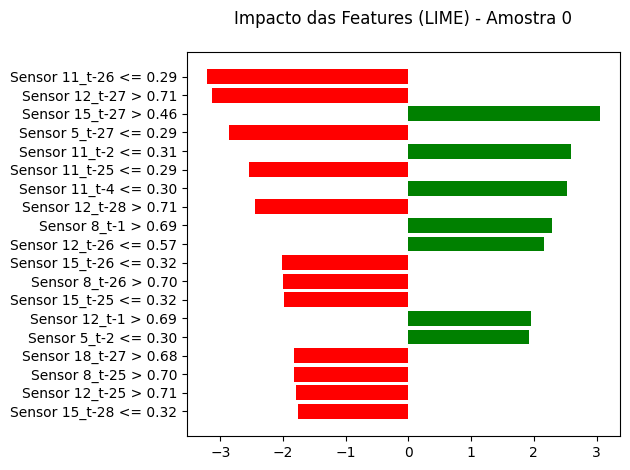

In [244]:
amostra_idx = 0

lime_explainer.plot_lime_explanation(amostra_idx)

In [245]:
#lime_explainer.save_and_open_html(amostra_idx)

## Integrated Gradients (IG)

In [246]:
from src.xai.xai_igExplainer import IntegratedGradientsExplainer

model_path = "../../models/best_models_cnn_lstm/best_cnn_lstm_FD001.keras"
x_path = "../../data/processed_data/X_test_FD001.npz"
y_path = "../../data/processed_data/y_test_FD001.npz"

ig_explainer = IntegratedGradientsExplainer(model_path, x_path, y_path)

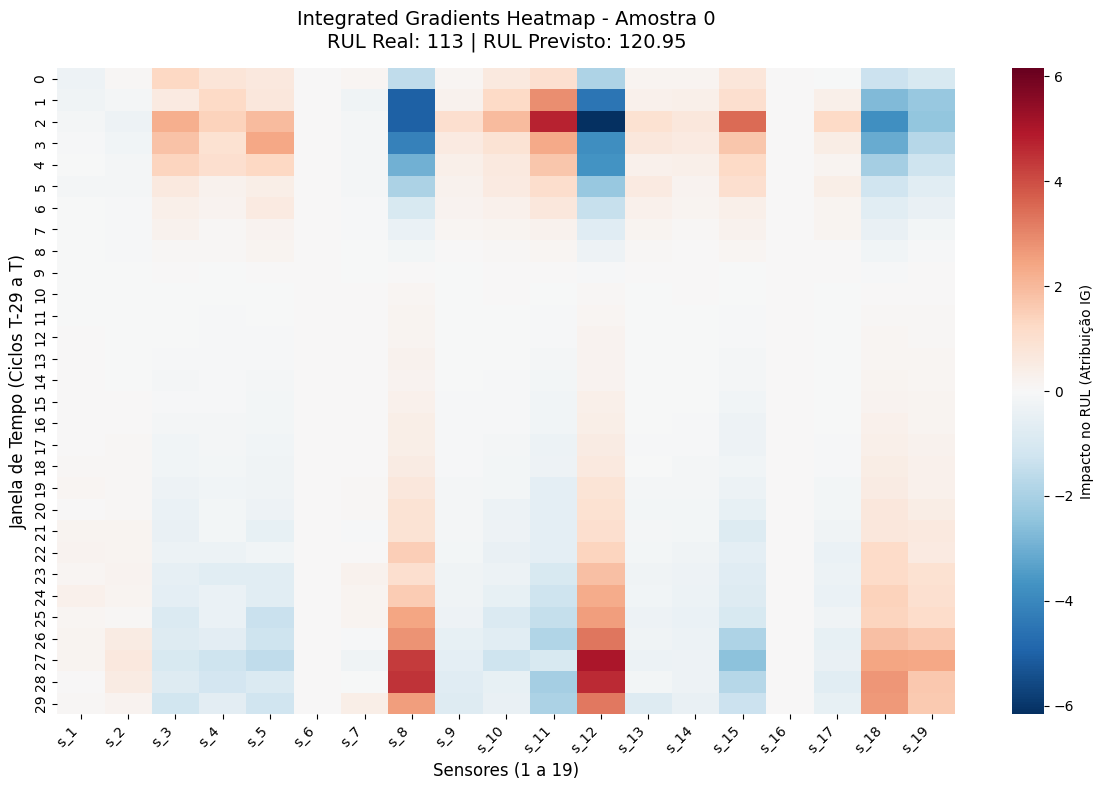

In [247]:
ig_explainer.plot_heatmap(index=0, m_steps=50)

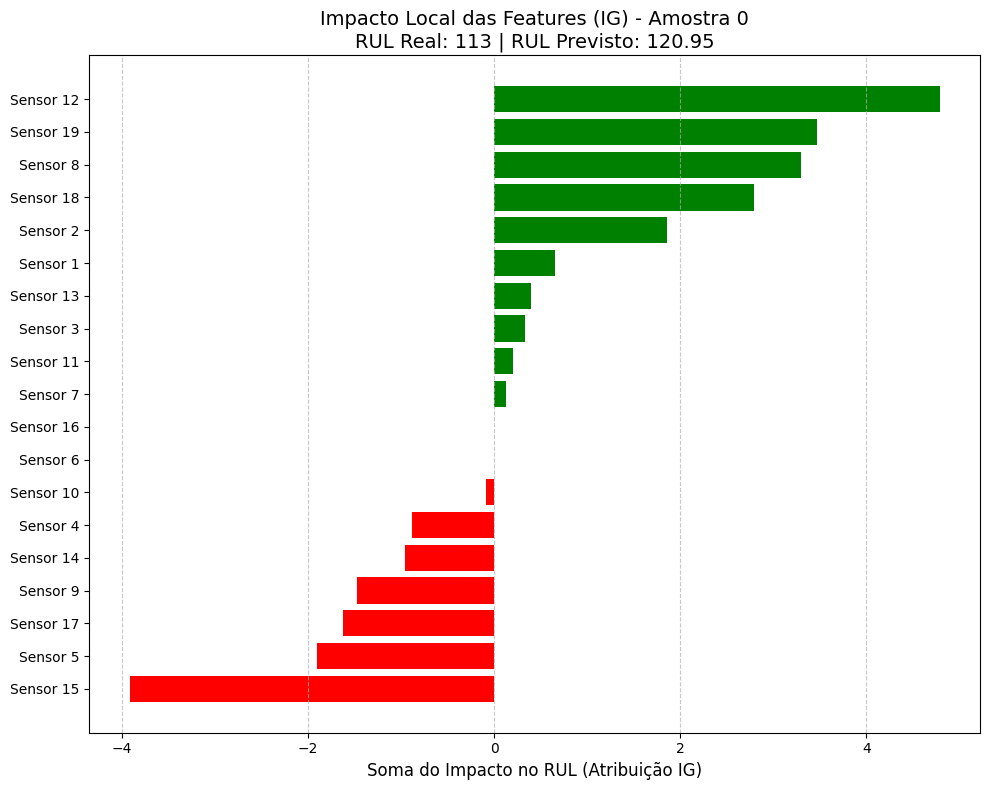

In [248]:
ig_explainer.plot_local_bar(index=0, m_steps=50)

Calculando IG global para 50 amostras. Isso pode levar alguns segundos...


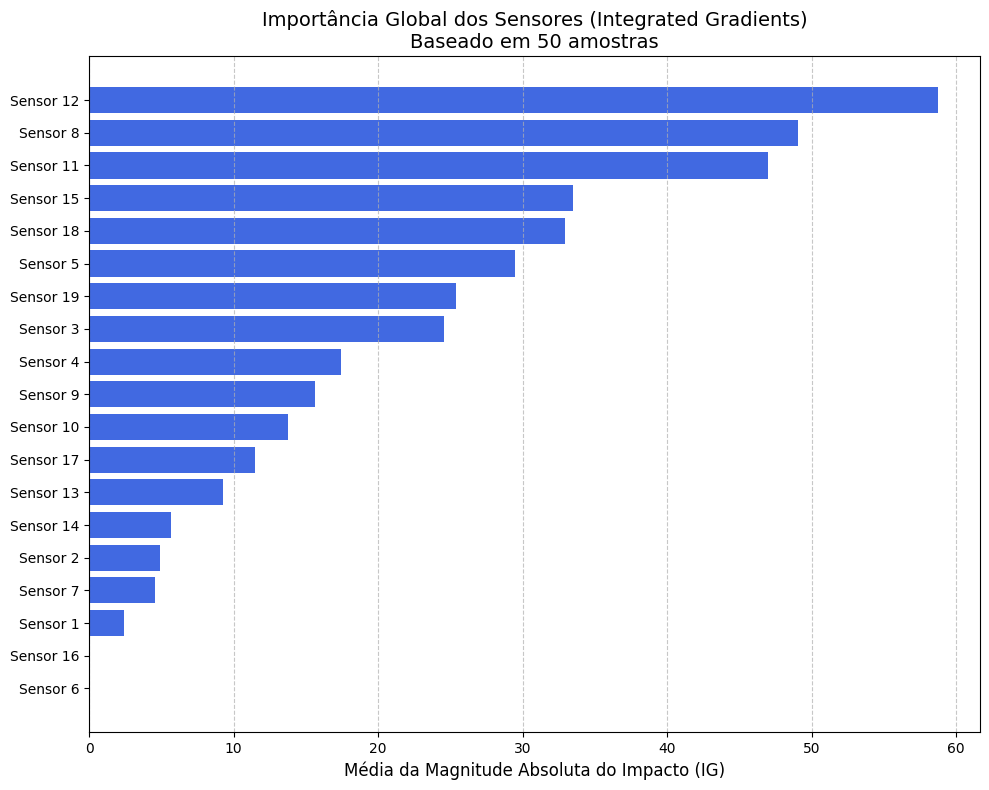

In [249]:
ig_explainer.plot_global_importance(num_samples=50, m_steps=50)

## TimeShap

In [250]:
from src.xai.xai_timeshapExplainer import TimeShapExplainer

model_path = "../../models/best_models_cnn_lstm/best_cnn_lstm_FD001.keras"
x_path = "../../data/processed_data/X_test_FD001.npz"
y_path = "../../data/processed_data/y_test_FD001.npz"

timeshap_explainer = TimeShapExplainer(model_path, x_path, y_path)

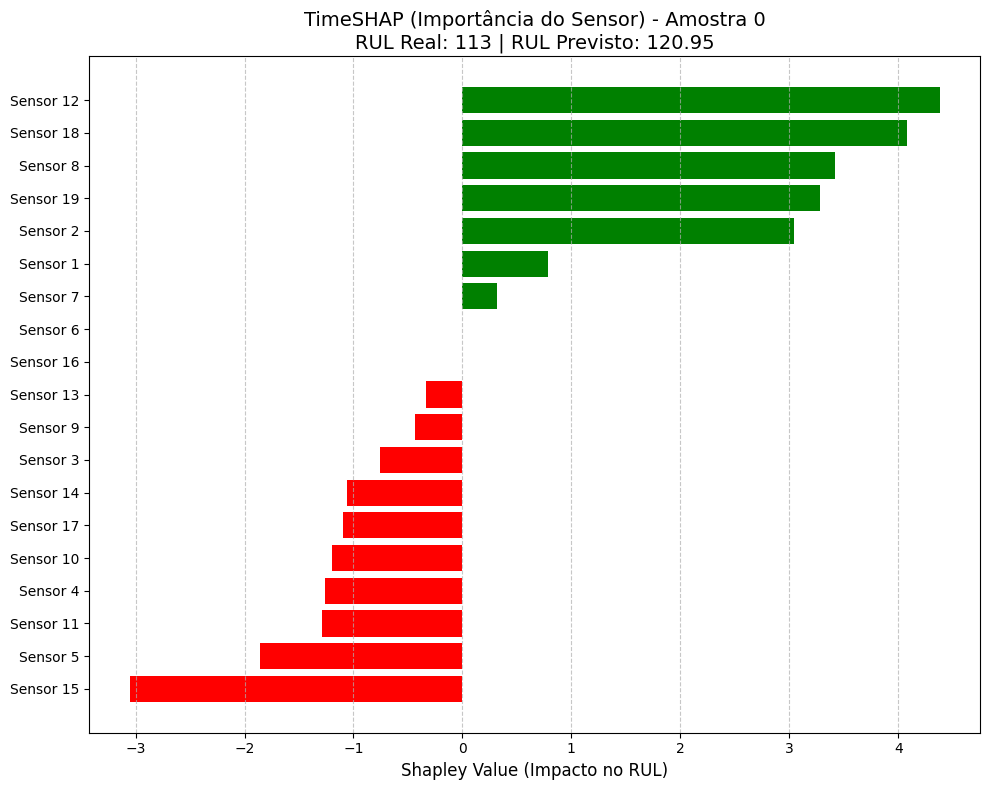

In [251]:
idx_teste = 0

timeshap_explainer.plot_feature_importance(idx_teste, n_samples=3200)

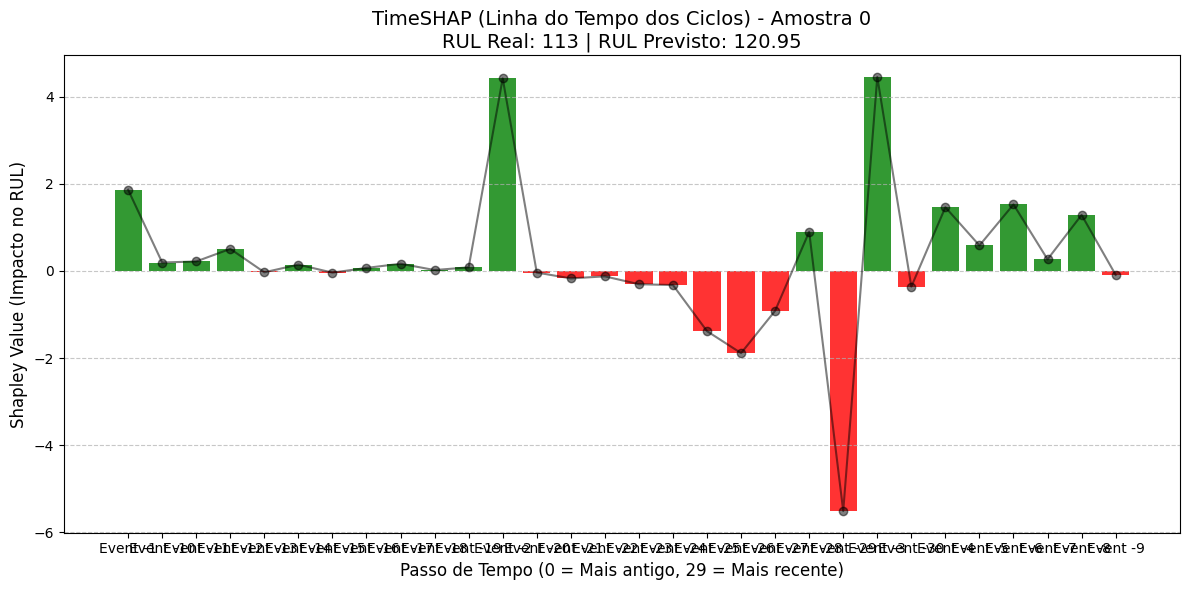

In [252]:
timeshap_explainer.plot_event_importance(idx_teste, n_samples=3200)

Calculando Pruning Temporal para a Amostra 0... (Tolerância: 5.0%)


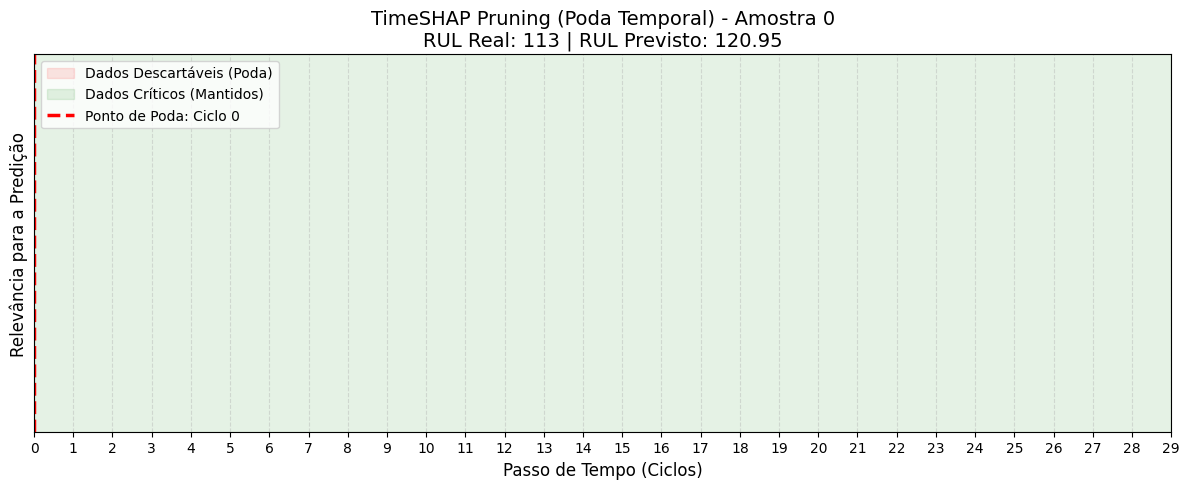

------------------------------------------------------------
RESULTADO DO PRUNING (Tolerância 5.0%):
-> Para manter a predição robusta, a CNN-LSTM precisa apenas dos ciclos 0 a 29.
-> Os ciclos iniciais de 0 a 0 não carregam impacto suficiente e podem ser podados.
------------------------------------------------------------


In [253]:
timeshap_explainer.plot_pruning(idx_teste, tolerance=0.05, n_samples=3200)

Calculando TimeSHAP Global para 10 amostras...


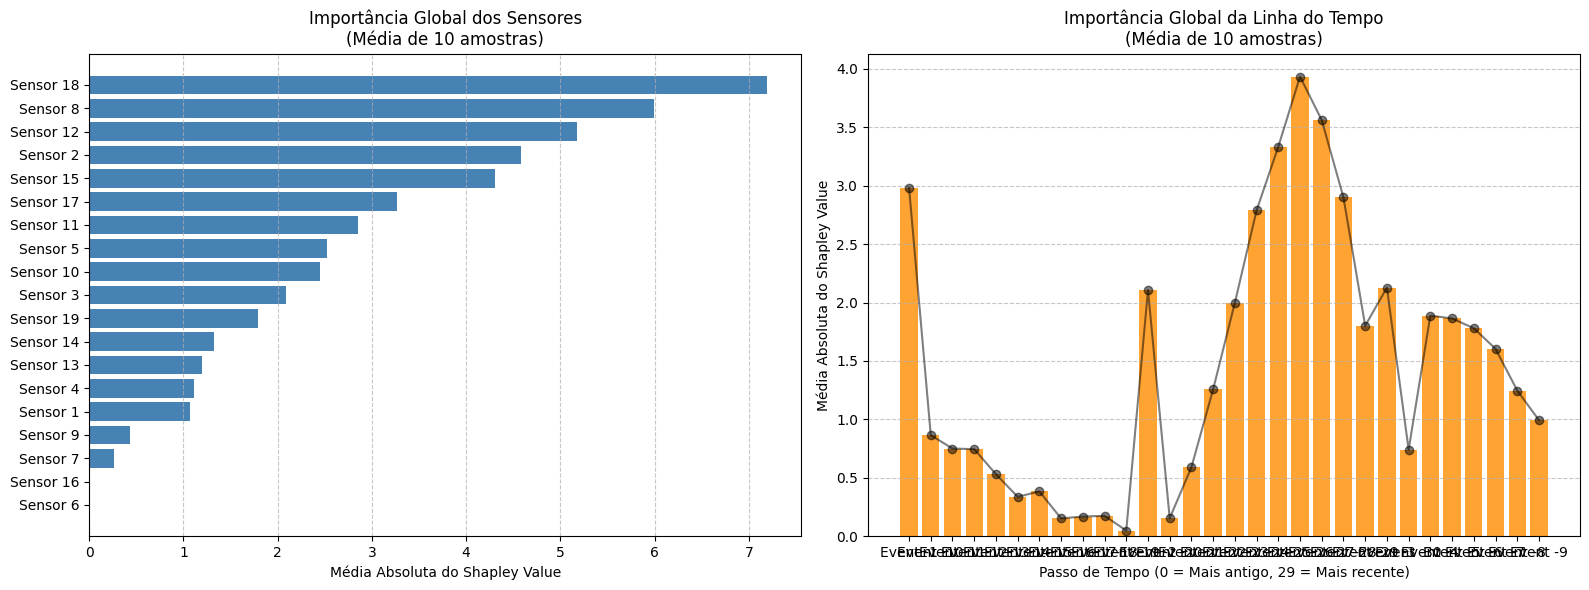

In [254]:
timeshap_explainer.plot_global_importance(num_instances=10, n_samples=3200)

## WindowSHAP

In [255]:
from src.xai.xai_windowshapExplainer import WindowShapExplainer

model_path = "../../models/best_models_cnn_lstm/best_cnn_lstm_FD001.keras"
x_path = "../../data/processed_data/X_test_FD001.npz"
y_path = "../../data/processed_data/y_test_FD001.npz"

windowshap_explainer = WindowShapExplainer(model_path, x_path, y_path)

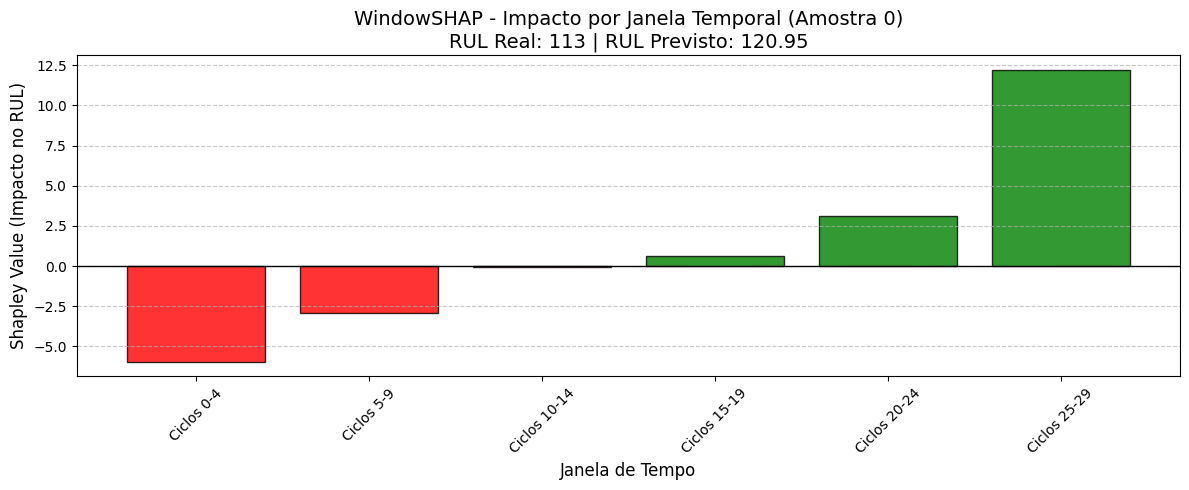

In [256]:
windowshap_explainer.plot_window_importance(idx_teste, n_samples=1000)

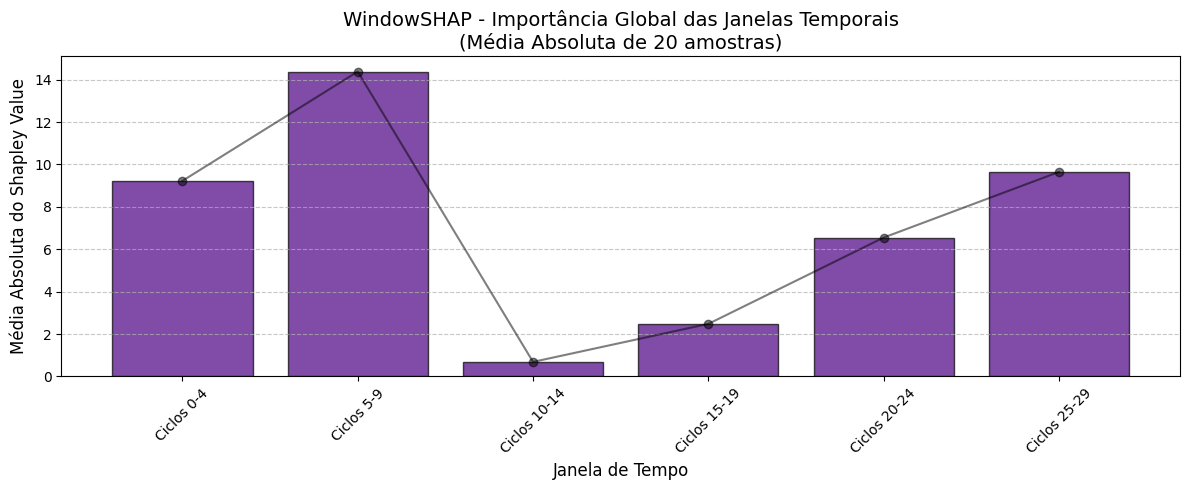

In [257]:
windowshap_explainer.plot_global_window_importance(num_instances=20, n_samples=1000)

## Grad-CAM

## Saliency Maps